Saved → ./clinical_trial_accuracy.png


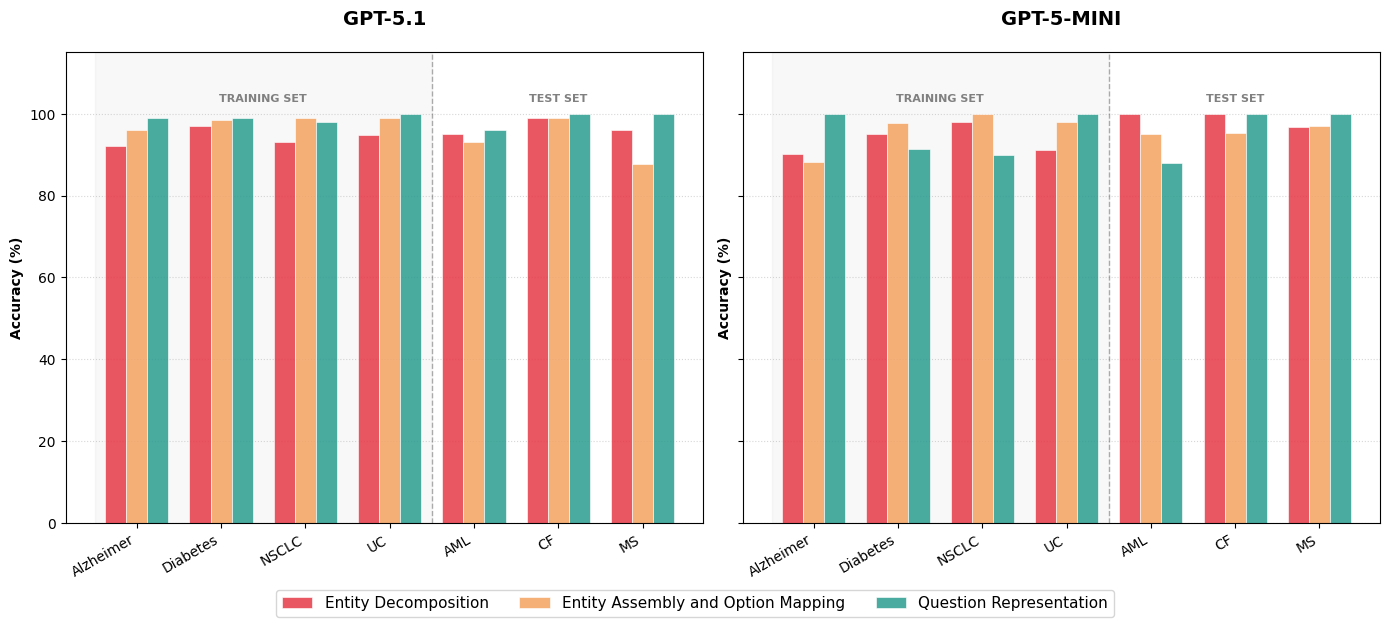

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Configuration ─────────────────────────────────────────────────────────────
PATH = "/Users/whitneyyu/Documents/research/clinicalTrial/2026/output/grade"
DISEASE_LST = ['Alzheimer', 'Diabetes', 'NSCLC', 'UC', 'AML', 'CF', 'MS']
MODELS = ['gpt-5.1', 'gpt-5-mini']
SHEET_CONFIG = {
    'attribute':        'Entity Decomposition',
    'option_attribute': 'Entity Assembly and Option Mapping',
    'option':           'Question Representation',
}
COLORS = {
    'Entity Decomposition':               '#E63946',
    'Entity Assembly and Option Mapping': '#F4A261',
    'Question Representation':            '#2A9D8F',
}

# ── Step 1: Load & aggregate data ─────────────────────────────────────────────
records = []
for model in MODELS:
    for dis in DISEASE_LST:
        fpath = os.path.join(PATH, f"ques_{model}_{dis}.xlsx")
        if not os.path.exists(fpath):
            print(f"  [skip] {fpath}")
            continue
        row = {'Disease Area': dis, 'Model': model}
        for sheet, label in SHEET_CONFIG.items():
            try:
                df = pd.read_excel(fpath, sheet_name=sheet)
                if 'Correct' in df.columns:
                    row[label] = pd.to_numeric(df['Correct'], errors='coerce').mean() * 100
                else:
                    row[label] = np.nan
            except Exception as e:
                print(f"  [warn] {fpath} / {sheet}: {e}")
                row[label] = np.nan
        records.append(row)

final_df = pd.DataFrame(records)

# ── Step 2: Plot ──────────────────────────────────────────────────────────────
LABELS  = list(SHEET_CONFIG.values())
x       = np.arange(len(DISEASE_LST))
width   = 0.25
offsets = [-width, 0, width]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    model_data = final_df[final_df['Model'] == model].set_index('Disease Area')

    for label, offset in zip(LABELS, offsets):
        vals = [model_data.loc[dis, label] if dis in model_data.index else np.nan
                for dis in DISEASE_LST]
        ax.bar(x + offset, vals, width=width, label=label,
               color=COLORS[label], alpha=0.85, edgecolor='white', linewidth=0.5)

    # Training / Test divider
    ax.axvspan(-0.5, 3.5, color='gray', alpha=0.05, zorder=0)
    ax.axvline(x=3.5, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax.text(1.5, 103, "TRAINING SET", ha='center', fontsize=8, fontweight='bold', color='gray')
    ax.text(5.0, 103, "TEST SET",     ha='center', fontsize=8, fontweight='bold', color='gray')

    # Formatting
    ax.set_title(model.upper(), fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(DISEASE_LST, rotation=30, ha='right', fontsize=10)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Accuracy (%)", fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)

# Shared legend
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.tight_layout()
out = './clinical_trial_accuracy.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved → {out}")
plt.show()

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# ── Configuration ─────────────────────────────────────────────────────────────
PATH = "/Users/whitneyyu/Documents/research/clinicalTrial/2026/output/grade"
DISEASE_LST = ['Alzheimer', 'Diabetes', 'NSCLC', 'UC', 'AML', 'CF', 'MS']
TRAINING_SET = ['Alzheimer', 'Diabetes', 'NSCLC', 'UC']   # first 4 per plot
TEST_SET     = ['AML', 'CF', 'MS']                        # last 3 per plot
MODELS = ['gpt-5.1', 'gpt-5-mini']
SHEET_CONFIG = {
    'attribute':        'Entity Decomposition',
    'option_attribute': 'Entity Assembly and Option Mapping',
    'option':           'Question Representation',
}

# ── Step 1: Load raw Correct columns (for t-tests) and compute accuracy ───────
# raw_data[model][disease][label] = array of 0/1 values
# acc_df: rows = (model, disease), cols = labels
raw_data = {m: {d: {} for d in DISEASE_LST} for m in MODELS}
records  = []

for model in MODELS:
    for dis in DISEASE_LST:
        fpath = os.path.join(PATH, f"ques_{model}_{dis}.xlsx")
        if not os.path.exists(fpath):
            print(f"  [skip] {fpath}")
            continue
        row = {'Disease Area': dis, 'Model': model}
        for sheet, label in SHEET_CONFIG.items():
            try:
                df   = pd.read_excel(fpath, sheet_name=sheet)
                vals = pd.to_numeric(df['Correct'], errors='coerce').dropna().values if 'Correct' in df.columns else np.array([])
                raw_data[model][dis][label] = vals
                row[label] = vals.mean() * 100 if len(vals) > 0 else np.nan
            except Exception as e:
                print(f"  [warn] {fpath}/{sheet}: {e}")
                raw_data[model][dis][label] = np.array([])
                row[label] = np.nan
        records.append(row)

acc_df = pd.DataFrame(records).set_index(['Model', 'Disease Area'])
LABELS = list(SHEET_CONFIG.values())

# ── Step 2: Overall accuracy range (all models, all domains) ──────────────────
all_vals = acc_df[LABELS].values.flatten()
overall_min = np.nanmin(all_vals)
overall_max = np.nanmax(all_vals)

print("=" * 60)
print("OVERALL ACCURACY")
print("=" * 60)
print(f"  Range across all domains & models: {overall_min:.1f}% – {overall_max:.1f}%")

# ── Step 3: Domain-level variance per model ───────────────────────────────────
print("\n" + "=" * 60)
print("DOMAIN-LEVEL ACCURACY VARIANCE (across disease areas)")
print("=" * 60)
for model in MODELS:
    model_acc = acc_df.loc[model, LABELS]          # shape: (7 diseases, 3 labels)
    # variance per label, then range of those variances
    variances = model_acc.var(axis=0)              # variance across 7 diseases, per label
    print(f"\n  {model}:")
    for label in LABELS:
        print(f"    {label}: var = {variances[label]:.2f}")
    print(f"    → variance range: {variances.min():.2f} – {variances.max():.2f}")

# ── Step 4: GPT-5.1 per-domain accuracy range & ranking ──────────────────────
print("\n" + "=" * 60)
print("GPT-5.1 ACCURACY BY DOMAIN (across disease areas)")
print("=" * 60)
gpt_acc = acc_df.loc['gpt-5.1', LABELS]
domain_stats = {}
for label in LABELS:
    col = gpt_acc[label]
    domain_stats[label] = {
        'min': col.min(),
        'max': col.max(),
        'mean': col.mean(),
    }
    print(f"  {label}: {col.min():.1f}% – {col.max():.1f}%  (mean {col.mean():.1f}%)")

ranked = sorted(domain_stats.items(), key=lambda x: -x[1]['mean'])
print("\n  Ranking (by mean accuracy):")
for rank, (label, s) in enumerate(ranked, 1):
    print(f"    {rank}. {label}: {s['min']:.1f}% – {s['max']:.1f}%")

# ── Step 5: Training vs Test set comparison (GPT-5.1, two-sample t-test) ──────
print("\n" + "=" * 60)
print("GPT-5.1 TRAINING vs TEST SET (two-sample t-test, per domain)")
print("=" * 60)
for label in LABELS:
    train_vals = np.concatenate([raw_data['gpt-5.1'][d][label]
                                 for d in TRAINING_SET if label in raw_data['gpt-5.1'][d]])
    test_vals  = np.concatenate([raw_data['gpt-5.1'][d][label]
                                 for d in TEST_SET  if label in raw_data['gpt-5.1'][d]])
    if len(train_vals) > 1 and len(test_vals) > 1:
        t_stat, p_val = stats.ttest_ind(train_vals, test_vals)
        sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
        print(f"  {label}:")
        print(f"    train mean = {train_vals.mean()*100:.1f}%  |  test mean = {test_vals.mean()*100:.1f}%")
        print(f"    t = {t_stat:.3f}, p = {p_val:.3f}  [{sig}]")
    else:
        print(f"  {label}: insufficient data for t-test")

# ── Step 6: Auto-fill paragraph ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("FILLED-IN PARAGRAPH")
print("=" * 60)

# variance range strings
def var_range(model):
    v = acc_df.loc[model, LABELS].var(axis=0)
    return f"{v.min():.2f} to {v.max():.2f}"

# per-domain accuracy range strings for gpt-5.1
def acc_range_str(label):
    col = acc_df.loc['gpt-5.1', label]
    return f"{col.min():.1f}% to {col.max():.1f}%"

# p-values
p_vals = {}
for label in LABELS:
    train_vals = np.concatenate([raw_data['gpt-5.1'][d][label]
                                 for d in TRAINING_SET if label in raw_data['gpt-5.1'][d]])
    test_vals  = np.concatenate([raw_data['gpt-5.1'][d][label]
                                 for d in TEST_SET  if label in raw_data['gpt-5.1'][d]])
    if len(train_vals) > 1 and len(test_vals) > 1:
        _, p = stats.ttest_ind(train_vals, test_vals)
        p_vals[label] = p
    else:
        p_vals[label] = float('nan')

r1, r2, r3 = ranked[0], ranked[1], ranked[2]

paragraph = f"""
Overall accuracy ranged from {overall_min:.1f}% to {overall_max:.1f}% across all domains.
GPT-5.1 demonstrated more consistent performance than GPT-5-mini.
Domain-level accuracy variance across disease areas was {var_range('gpt-5.1')} for GPT-5.1
and {var_range('gpt-5-mini')} for GPT-5-mini. The higher variance observed in GPT-5-mini
likely reflects sampling effects: performance in a given disease area is sensitive to whether
the sampled tasks happen to align with the model's strengths in that domain. For this reason,
the following discussion focuses on GPT-5.1.

GPT-5.1 performed best in {r1[0]}, with accuracy ranging from {acc_range_str(r1[0])},
followed by {r2[0]} ({acc_range_str(r2[0])}) and {r3[0]} ({acc_range_str(r3[0])}).
Performance did not differ significantly between the training and test sets in any domain
(Entity Decomposition: p = {p_vals['Entity Decomposition']:.3f};
 Entity Assembly and Option Mapping: p = {p_vals['Entity Assembly and Option Mapping']:.3f};
 Question Representation: p = {p_vals['Question Representation']:.3f}),
supporting the generalizability of the approach.
"""
print(paragraph)

OVERALL ACCURACY
  Range across all domains & models: 87.8% – 100.0%

DOMAIN-LEVEL ACCURACY VARIANCE (across disease areas)

  gpt-5.1:
    Entity Decomposition: var = 5.53
    Entity Assembly and Option Mapping: var = 24.90
    Question Representation: var = 2.07
    → variance range: 2.07 – 24.90

  gpt-5-mini:
    Entity Decomposition: var = 15.76
    Entity Assembly and Option Mapping: var = 14.31
    Question Representation: var = 30.70
    → variance range: 14.31 – 30.70

GPT-5.1 ACCURACY BY DOMAIN (across disease areas)
  Entity Decomposition: 92.1% – 99.0%  (mean 95.3%)
  Entity Assembly and Option Mapping: 87.8% – 99.0%  (mean 94.6%)
  Question Representation: 96.1% – 100.0%  (mean 98.8%)

  Ranking (by mean accuracy):
    1. Question Representation: 96.1% – 100.0%
    2. Entity Decomposition: 92.1% – 99.0%
    3. Entity Assembly and Option Mapping: 87.8% – 99.0%

GPT-5.1 TRAINING vs TEST SET (two-sample t-test, per domain)
  Entity Decomposition:
    train mean = 94.2%  |  te